# Clinical Trial Footprint vs. Population Structure

**Course:** Data Science — Regular Exam, March 2026  
**Author:** Momchil Ivanov  
**Deadline:** 28 April 2026, 16:00h  
**Repository:** [github.com/Momchil-Ivanov/Data-Science-Mar-2026](https://github.com/Momchil-Ivanov/Data-Science-Mar-2026/tree/clinical-trial-footprint-vs-population-structure)

---

## Section 0 — Introduction & Problem Formulation

### 0.1 Motivation

Clinical trials are the gold standard for establishing the safety and efficacy of new medical treatments. Where these trials are conducted matters enormously: countries that host more trials gain earlier access to experimental therapies, attract research investment, and build local scientific capacity. Countries that are systematically underrepresented risk falling behind in medical innovation and having treatments developed without sufficient data from their populations.

This project asks a simple but revealing question: **is the global distribution of clinical trials proportional to where people actually live?** Or is it skewed — concentrated in wealthy, high-income countries regardless of population size?

We use two independent public data sources:

| Source | What it provides | Access |
|---|---|---|
| **ClinicalTrials.gov** | Trial recruitment site counts per country, phase, status, start year | REST API v2 — `https://clinicaltrials.gov/api/v2/` |
| **World Bank Indicators** | Population, GDP per capita, world region, income group | REST API v2 — `https://api.worldbank.org/v2/` |

Both sources are freely accessible without authentication and are maintained by authoritative international institutions (U.S. National Library of Medicine and the World Bank Group, respectively).

> **Reproducibility note:** No data files are committed to this repository. All data is fetched from the APIs above at runtime. Running Section 1 from top to bottom will recreate the full dataset.

---

### 0.2 Research Questions

We investigate four concrete questions. The appropriate statistical methods and formal hypotheses for each will be introduced in the relevant analysis section, after the data has been inspected.

1. **Q1 — Income groups:** How many trials per million inhabitants do different countries have, and how does this differ between income groups?
2. **Q2 — Population scaling:** Does a larger population proportionally lead to more trials, or is the relationship sub- or super-linear?
3. **Q3 — Regional inequality:** Is there a systematic difference in trial density across world regions, and how concentrated is the global distribution?
4. **Q4 — Temporal trends:** How has the picture changed over time (2000–2024), and is the gap between income groups growing or shrinking?

---

### 0.3 Prior Work

The unequal global distribution of clinical trials has been documented under the label of the **"10/90 gap"** — roughly 90 % of global health research funding addresses diseases affecting only 10 % of the world's population (Global Forum for Health Research, 2000). Viergever & Li (2015) mapped trial density globally using the WHO ICTRP registry and found a strong positive correlation with GDP per capita. Drain et al. (2014) showed that high-income countries account for the large majority of trial sites despite representing a minority of global disease burden.

This project extends that work by explicitly testing whether the population-to-trial relationship is proportional, and by applying distributional inequality tools (Lorenz curve, Gini coefficient) to quantify concentration rather than relying on regional averages alone.

In [1]:
import requests
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pycountry
import statsmodels.formula.api as smf
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu
from itertools import combinations
import plotly.express as px

print('All imports OK')

All imports OK


## Section 1 — Data Ingestion

### 1.1 ClinicalTrials.gov API v2

We fetch trial metadata directly from the ClinicalTrials.gov REST API v2. No files are stored in the repository — data is recreated at runtime on every run.

**What we extract per study:**
- `nctId` — unique trial identifier
- `startDate` — trial start date (we keep the year)
- `locations[].country` — every country where the trial recruits participants

**Unit of measurement:** a single multinational trial with sites in 30 countries contributes **1 count to each of those 30 countries**. We therefore measure *trial-site presence per country*, not globally unique trials. This is a deliberate choice: it reflects the research activity actually experienced by a given country's population.

**Filters applied at fetch time:**
- `overallStatus`: `COMPLETED`, `ACTIVE_NOT_RECRUITING`, `RECRUITING` — excludes withdrawn/terminated studies with no recruitment activity.

In [2]:
CT_BASE = "https://clinicaltrials.gov/api/v2/studies"

CT_PARAMS = {
    "format": "json",
    "pageSize": 1000,
    "fields": "NCTId,StartDate,LocationCountry",
    "filter.overallStatus": "COMPLETED,ACTIVE_NOT_RECRUITING,RECRUITING",
}


def ct_get_page(params: dict, max_retries: int = 5) -> dict:
    """Fetch one ClinicalTrials.gov page, retrying transient network failures."""
    for attempt in range(1, max_retries + 1):
        try:
            resp = requests.get(CT_BASE, params=params, timeout=(15, 90))
            resp.raise_for_status()
            return resp.json()
        except requests.exceptions.RequestException as exc:
            if attempt == max_retries:
                page_token = params.get("pageToken", "first page")
                raise RuntimeError(f"ClinicalTrials.gov request failed at {page_token}") from exc

            wait_seconds = 2 ** attempt
            print(f"ClinicalTrials.gov request failed; retrying in {wait_seconds}s ({attempt}/{max_retries})")
            time.sleep(wait_seconds)


def fetch_clinicaltrials() -> pd.DataFrame:
    """Page through ClinicalTrials.gov API v2 and return one row per
    (nct_id, country, start_year) triplet."""
    records = []
    params = CT_PARAMS.copy()
    page_count = 0

    while True:
        data = ct_get_page(params)
        page_count += 1

        for study in data.get("studies", []):
            proto = study.get("protocolSection", {})
            nct_id = proto.get("identificationModule", {}).get("nctId", "")
            start_raw = proto.get("statusModule", {}).get("startDateStruct", {}).get("date", "")
            start_year = int(start_raw[:4]) if start_raw and len(start_raw) >= 4 else None
            locations = proto.get("contactsLocationsModule", {}).get("locations", [])
            countries = {loc.get("country") for loc in locations if loc.get("country")}
            for country in countries:
                records.append({"nct_id": nct_id, "country": country, "start_year": start_year})

        if page_count % 25 == 0:
            print(f"Fetched {page_count:,} pages so far...")

        next_token = data.get("nextPageToken")
        if not next_token:
            break
        params["pageToken"] = next_token
        time.sleep(0.2)  # stay within API rate limits

    df = pd.DataFrame(records)
    print(f"Fetched {df['nct_id'].nunique():,} unique studies → {len(df):,} (study, country) pairs")
    print(f"Unique country names in raw data: {df['country'].nunique()}")
    return df

ct_raw = fetch_clinicaltrials()
ct_raw.head()

Fetched 25 pages so far...
Fetched 50 pages so far...
Fetched 75 pages so far...
Fetched 100 pages so far...
Fetched 125 pages so far...
Fetched 150 pages so far...
Fetched 175 pages so far...
Fetched 200 pages so far...
Fetched 225 pages so far...
Fetched 250 pages so far...
Fetched 275 pages so far...
Fetched 300 pages so far...
Fetched 325 pages so far...
Fetched 350 pages so far...
Fetched 375 pages so far...
Fetched 400 pages so far...
Fetched 380,990 unique studies → 576,982 (study, country) pairs
Unique country names in raw data: 219


,nct_id,country,start_year
0,NCT00478192,India,2007.0
1,NCT00478192,United States,2007.0
2,NCT05189171,United States,2022.0
3,NCT05077436,United Kingdom,2021.0
4,NCT06766136,Turkey (Türkiye),2024.0


### 1.2 World Bank Indicators API

We fetch country-level demographic and economic context directly from the World Bank REST API. These variables are needed to compare clinical trial activity against the size and development level of each country's population.

**What we extract per country:**
- `iso3` — ISO 3166-1 alpha-3 country code, used as the stable merge key
- `country` — World Bank country name
- `region` — World Bank region classification
- `income_group` — World Bank income group classification
- `population` — total population (`SP.POP.TOTL`)
- `gdp_per_capita_usd` — GDP per capita in current US dollars (`NY.GDP.PCAP.CD`)

We use **2023** as the reference year because it is recent while usually having broader coverage than the most recent calendar year. Aggregates such as "World" or "High income" are excluded, leaving only country-level records.

In [3]:
WB_BASE = "https://api.worldbank.org/v2"
WB_YEAR = 2023

WB_INDICATORS = {
    "population": "SP.POP.TOTL",
    "gdp_per_capita_usd": "NY.GDP.PCAP.CD",
}


def wb_get(path: str, params: dict | None = None) -> list[dict]:
    """Request one World Bank API endpoint and return the data payload."""
    request_params = {"format": "json", "per_page": 1000}
    if params:
        request_params.update(params)

    resp = requests.get(f"{WB_BASE}/{path}", params=request_params, timeout=30)
    resp.raise_for_status()
    payload = resp.json()

    if not isinstance(payload, list) or len(payload) < 2:
        return []
    return payload[1] or []


def fetch_country_metadata() -> pd.DataFrame:
    """Fetch country names, ISO codes, regions, and income groups."""
    records = []

    for item in wb_get("country"):
        region = item.get("region", {})
        income_group = item.get("incomeLevel", {})

        # World Bank aggregate regions have region id "NA"; keep countries only.
        if region.get("id") == "NA":
            continue

        records.append(
            {
                "iso3": item.get("id"),
                "iso2": item.get("iso2Code"),
                "country": item.get("name"),
                "region": region.get("value"),
                "income_group": income_group.get("value"),
            }
        )

    return pd.DataFrame(records)


def fetch_wb_indicator(indicator: str, value_col: str, year: int = WB_YEAR) -> pd.DataFrame:
    """Fetch one World Bank indicator for all countries in a given year."""
    records = []

    for item in wb_get(f"country/all/indicator/{indicator}", {"date": str(year)}):
        iso3 = item.get("countryiso3code")
        value = item.get("value")
        if iso3 and value is not None:
            records.append({"iso3": iso3, value_col: value})

    return pd.DataFrame(records)


wb_meta = fetch_country_metadata()
wb_pop = fetch_wb_indicator(WB_INDICATORS["population"], "population")
wb_gdp = fetch_wb_indicator(WB_INDICATORS["gdp_per_capita_usd"], "gdp_per_capita_usd")

wb_raw = wb_meta.merge(wb_pop, on="iso3", how="left").merge(wb_gdp, on="iso3", how="left")

print(f"Fetched World Bank metadata for {len(wb_raw):,} countries")
print(f"Countries with population in {WB_YEAR}: {wb_raw['population'].notna().sum():,}")
print(f"Countries with GDP per capita in {WB_YEAR}: {wb_raw['gdp_per_capita_usd'].notna().sum():,}")

wb_raw.head()

Fetched World Bank metadata for 217 countries
Countries with population in 2023: 217
Countries with GDP per capita in 2023: 203


,iso3,iso2,country,region,income_group,population,gdp_per_capita_usd
0,ABW,AW,Aruba,Latin America & Caribbean,High income,107359,35718.753119
1,AFG,AF,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income,41454761,413.757895
2,AGO,AO,Angola,Sub-Saharan Africa,Lower middle income,36749906,2916.136633
3,ALB,AL,Albania,Europe & Central Asia,Upper middle income,2414095,9730.869219
4,AND,AD,Andorra,Europe & Central Asia,High income,80856,46812.426101


## Section 2 — Data Inspection & Cleaning

### 2.1 Inspect raw ClinicalTrials.gov data

Before cleaning or merging, we inspect the raw ClinicalTrials.gov extraction. This tells us:

- how many rows and columns were fetched;
- which data types pandas assigned;
- whether key fields are missing;
- what year range the trials cover;
- which country names appear most often.

This step is important because the next cleaning step depends on what the raw API data actually looks like.

In [4]:
print("=== ClinicalTrials.gov raw data shape ===")
print(ct_raw.shape)

print("\n=== Column data types ===")
print(ct_raw.dtypes)

print("\n=== Missing values ===")
print(ct_raw.isnull().sum())

print("\n=== Start year coverage ===")
print(ct_raw["start_year"].describe())

print("\n=== Top 20 raw country names ===")
print(ct_raw["country"].value_counts().head(20))

=== ClinicalTrials.gov raw data shape ===
(576982, 3)

=== Column data types ===
nct_id         object
country        object
start_year    float64
dtype: object

=== Missing values ===
nct_id           0
country          0
start_year    2367
dtype: int64

=== Start year coverage ===
count    574615.000000
mean       2016.075122
std           6.760820
min        1916.000000
25%        2011.000000
50%        2017.000000
75%        2022.000000
max        2030.000000
Name: start_year, dtype: float64

=== Top 20 raw country names ===
country
United States       150093
France               30677
China                28812
Canada               24551
Germany              22277
United Kingdom       21713
Turkey (Türkiye)     19321
Spain                18995
Italy                18862
South Korea          12818
Belgium              11820
Netherlands          11478
Egypt                10710
Australia             9795
Denmark               9774
Poland                8989
Taiwan                840

### 2.2 Standardise ClinicalTrials.gov country names

ClinicalTrials.gov gives country names as free-text strings, while the World Bank data uses standard ISO country codes. To merge both sources later, we need a shared country key.

We convert each ClinicalTrials.gov country name to an ISO2 code using `pycountry`. Some country names require manual overrides because API naming conventions differ from ISO naming conventions (for example, `Turkey (Türkiye)`, `South Korea`, or `Taiwan`).

The result of this step is a new `iso2` column in `ct_raw`. Any unresolved country names are printed so they can be inspected before the merge.

In [5]:
CT_COUNTRY_OVERRIDES = {
    "Bolivia": "BO",
    "Congo, The Democratic Republic of the": "CD",
    "Czechia": "CZ",
    "Hong Kong": "HK",
    "Iran": "IR",
    "Kosovo": "XK",
    "Moldova": "MD",
    "North Korea": "KP",
    "Palestine": "PS",
    "Russia": "RU",
    "South Korea": "KR",
    "Taiwan": "TW",
    "Tanzania": "TZ",
    "Turkey (Türkiye)": "TR",
    "Venezuela": "VE",
    "Vietnam": "VN",
}


def country_to_iso2(country_name: str) -> str | None:
    """Map a ClinicalTrials.gov country name to an ISO2 country code."""
    if pd.isna(country_name):
        return None

    country_name = str(country_name).strip()

    if country_name in CT_COUNTRY_OVERRIDES:
        return CT_COUNTRY_OVERRIDES[country_name]

    try:
        return pycountry.countries.lookup(country_name).alpha_2
    except LookupError:
        return None


ct_raw["iso2"] = ct_raw["country"].map(country_to_iso2)

unresolved = (
    ct_raw.loc[ct_raw["iso2"].isna(), "country"]
    .value_counts()
    .rename_axis("country")
    .reset_index(name="rows")
)

print(f"Mapped ISO2 codes for {ct_raw['iso2'].notna().sum():,} rows")
print(f"Unresolved rows: {ct_raw['iso2'].isna().sum():,}")
print(f"Unresolved unique country names: {len(unresolved):,}")

unresolved.head(20)

Mapped ISO2 codes for 576,389 rows
Unresolved rows: 593
Unresolved unique country names: 17


,country,rows
0,Democratic Republic of the Congo,141
1,Reunion,89
2,Côte d’Ivoire,86
3,The Gambia,79
4,Palestinian Territories,71
5,Burma,36
6,Serbia and Montenegro,34
7,The Bahamas,16
8,Macau,15
9,Brunei,8


### 2.3 Build cleaned ClinicalTrials.gov trial counts

Now that each ClinicalTrials.gov row has a standard country code, we build the cleaned trial-count tables used later in the analysis.

Cleaning rules:

- remove rows without an `iso2` country code;
- remove rows without `start_year`;
- keep trials from **2000–2024** only;
- convert `start_year` from float to integer;
- aggregate to two useful tables:
  - `ct_panel`: trial counts by country and year;
  - `ct_total`: total trial counts by country across the whole analysis period.

The year filter is needed because the raw data includes very old records and future planned trials; the project focuses on the modern ClinicalTrials.gov era.

In [6]:
ANALYSIS_START_YEAR = 2000
ANALYSIS_END_YEAR = 2024

ct_clean = (
    ct_raw
    .dropna(subset=["iso2", "start_year"])
    .query("@ANALYSIS_START_YEAR <= start_year <= @ANALYSIS_END_YEAR")
    .copy()
)

ct_clean["start_year"] = ct_clean["start_year"].astype(int)

ct_panel = (
    ct_clean
    .groupby(["iso2", "start_year"], as_index=False)
    .agg(trial_count=("nct_id", "count"))
)

ct_total = (
    ct_clean
    .groupby("iso2", as_index=False)
    .agg(trial_count=("nct_id", "count"))
)

print(f"Rows before cleaning: {len(ct_raw):,}")
print(f"Rows after cleaning: {len(ct_clean):,}")
print(f"Dropped rows: {len(ct_raw) - len(ct_clean):,}")
print(f"Country-year rows in ct_panel: {len(ct_panel):,}")
print(f"Countries in ct_total: {len(ct_total):,}")

ct_total.sort_values("trial_count", ascending=False).head(10)

Rows before cleaning: 576,982
Rows after cleaning: 525,829
Dropped rows: 51,153
Country-year rows in ct_panel: 3,398
Countries in ct_total: 202


,iso2,trial_count
188,US,135732
57,FR,28414
34,CN,23792
28,CA,22805
42,DE,20959
59,GB,20289
52,ES,17447
86,IT,17212
181,TR,16148
98,KR,12010


### 2.4 Merge trial counts with World Bank country data

The cleaned ClinicalTrials.gov table gives us trial activity by country code, but it does not contain population, income group, region, or GDP per capita. We merge `ct_total` with the World Bank table `wb_raw` using the shared `iso2` country code.

The resulting table `df` is the main cross-sectional dataset for later analysis. Each row represents one country and contains:

- country identifiers and name;
- World Bank region and income group;
- population and GDP per capita for the reference year;
- total ClinicalTrials.gov trial-site count for 2000–2024.

We inspect merge coverage immediately to make sure we are not losing many countries before calculating trial density.

In [7]:
df = (
    ct_total
    .merge(wb_raw, on="iso2", how="inner")
    .sort_values("trial_count", ascending=False)
    .reset_index(drop=True)
)

unmatched_ct = ct_total.loc[~ct_total["iso2"].isin(wb_raw["iso2"])]

print(f"ClinicalTrials.gov countries before merge: {len(ct_total):,}")
print(f"World Bank country rows: {len(wb_raw):,}")
print(f"Matched countries in merged dataset: {len(df):,}")
print(f"ClinicalTrials.gov countries not matched to World Bank: {len(unmatched_ct):,}")

print("\nMissing values after merge:")
print(df[["population", "gdp_per_capita_usd", "region", "income_group"]].isnull().sum())

print("\nUnmatched ClinicalTrials.gov country codes:")
print(unmatched_ct.sort_values("trial_count", ascending=False).head(20))

df.head(10)

ClinicalTrials.gov countries before merge: 202
World Bank country rows: 217
Matched countries in merged dataset: 192
ClinicalTrials.gov countries not matched to World Bank: 10

Missing values after merge:
population             0
gdp_per_capita_usd    10
region                 0
income_group           0
dtype: int64

Unmatched ClinicalTrials.gov country codes:
    iso2  trial_count
183   TW         7721
122   MQ           73
67    GP           65
62    GF           26
198   YT            5
140   NU            4
87    JE            2
39    CX            1
124   MS            1
187   UM            1


,iso2,trial_count,iso3,country,region,income_group,population,gdp_per_capita_usd
0,US,135732,USA,United States,North America,High income,336806231,81032.262118
1,FR,28414,FRA,France,Europe & Central Asia,High income,68372286,44700.138418
2,CN,23792,CHN,China,East Asia & Pacific,Upper middle income,1410710000,12951.178240
3,CA,22805,CAN,Canada,North America,High income,40083484,54220.328504
4,DE,20959,DEU,Germany,Europe & Central Asia,High income,83287273,54776.766824
5,GB,20289,GBR,United Kingdom,Europe & Central Asia,High income,68492000,49944.470212
6,ES,17447,ESP,Spain,Europe & Central Asia,High income,48352528,33493.222541
7,IT,17212,ITA,Italy,Europe & Central Asia,High income,58984216,39277.083878
8,TR,16148,TUR,Turkiye,Europe & Central Asia,Upper middle income,85325965,13375.094728
9,KR,12010,KOR,"Korea, Rep.",East Asia & Pacific,High income,51712619,35674.095996


### 2.5 Derive analysis variables

After merging trial counts with population and economic metadata, we compute the variables that will be used in the exploratory and statistical analysis.

Derived variables:

- `trial_density` — trials per million inhabitants;
- `log_trials` — log-transformed trial count, used later for regression;
- `log_population` — log-transformed population;
- `log_gdp_per_capita` — log-transformed GDP per capita, used for context and possible sensitivity checks.

The most important variable is `trial_density`, because raw trial counts are not directly comparable across countries with very different population sizes.

In [8]:
df = df.copy()

df["trial_density"] = df["trial_count"] / df["population"] * 1_000_000
df["log_trials"] = np.log10(df["trial_count"] + 1)
df["log_population"] = np.log10(df["population"])
df["log_gdp_per_capita"] = np.log10(df["gdp_per_capita_usd"])

analysis_columns = [
    "trial_count",
    "population",
    "trial_density",
    "gdp_per_capita_usd",
    "log_trials",
    "log_population",
    "log_gdp_per_capita",
]

print("Derived analysis variables added:")
print(["trial_density", "log_trials", "log_population", "log_gdp_per_capita"])

print("\nSummary statistics:")
df[analysis_columns].describe().round(2)

Derived analysis variables added:
['trial_density', 'log_trials', 'log_population', 'log_gdp_per_capita']

Summary statistics:


,trial_count,population,trial_density,gdp_per_capita_usd,log_trials,log_population,log_gdp_per_capita
count,192.00,1.920000e+02,192.00,182.00,192.00,192.00,182.00
mean,2697.55,4.082695e+07,130.05,22089.39,2.17,6.79,3.92
std,10709.92,1.505476e+08,259.13,34305.03,1.19,0.96,0.65
min,1.00,3.386000e+04,0.04,250.63,0.30,4.53,2.40
25%,16.75,1.874670e+06,5.09,2676.83,1.25,6.27,3.43
50%,123.50,9.010292e+06,18.18,7814.59,2.10,6.95,3.89
75%,1245.00,2.870317e+07,105.47,27748.16,3.09,7.46,4.44
max,135732.00,1.438070e+09,2079.27,256799.79,5.13,9.16,5.41


## Section 3 — Exploratory Data Analysis

### 3.1 Inspect distributions of analysis variables

Before choosing formal statistical tests, we first inspect the distributions of the main numeric variables. This helps us see whether the data is approximately symmetric or strongly skewed.

In particular, we compare raw variables with their log-transformed versions:

- `trial_count` vs `log_trials`;
- `trial_density`;
- `population` vs `log_population`.

If raw variables are heavily right-skewed, later group comparisons should avoid methods that assume normality, and regression should usually be performed on the log scale.

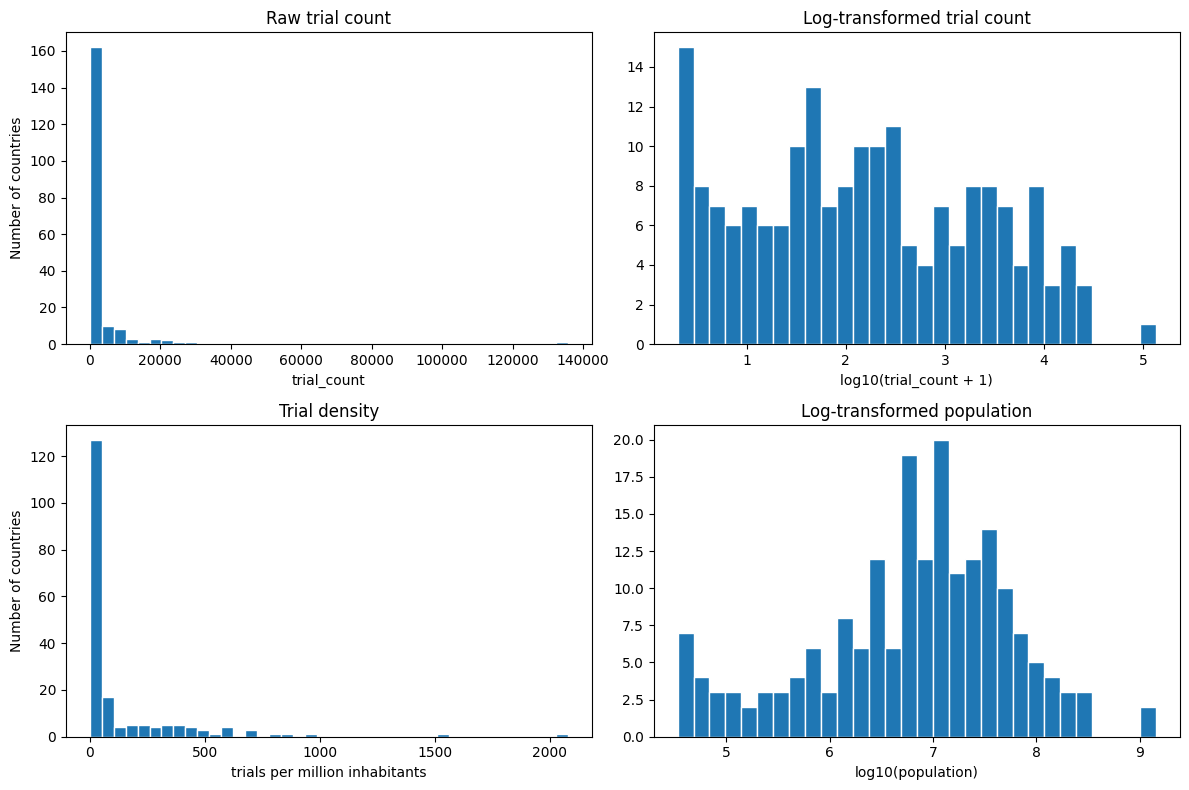

Skewness of selected variables:
trial_count       10.38
trial_density      3.85
population         8.31
log_trials         0.17
log_population    -0.50
dtype: float64


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(df["trial_count"], bins=40, edgecolor="white")
axes[0, 0].set_title("Raw trial count")
axes[0, 0].set_xlabel("trial_count")
axes[0, 0].set_ylabel("Number of countries")

axes[0, 1].hist(df["log_trials"], bins=30, edgecolor="white")
axes[0, 1].set_title("Log-transformed trial count")
axes[0, 1].set_xlabel("log10(trial_count + 1)")

axes[1, 0].hist(df["trial_density"], bins=40, edgecolor="white")
axes[1, 0].set_title("Trial density")
axes[1, 0].set_xlabel("trials per million inhabitants")
axes[1, 0].set_ylabel("Number of countries")

axes[1, 1].hist(df["log_population"], bins=30, edgecolor="white")
axes[1, 1].set_title("Log-transformed population")
axes[1, 1].set_xlabel("log10(population)")

plt.tight_layout()
plt.show()

print("Skewness of selected variables:")
print(df[["trial_count", "trial_density", "population", "log_trials", "log_population"]].skew().round(2))

### 3.2 Q1 — Trial density by income group

**Research question:** Do countries in different World Bank income groups host systematically different numbers of clinical trials per million inhabitants?

**Hypotheses:**
- **H₀:** The median trial density is the same across all four income groups.
- **H₁:** At least one income group has a different median trial density.

We use the **Kruskal-Wallis H-test** rather than one-way ANOVA because Section 3.1 showed that `trial_density` is strongly right-skewed (skewness ≈ 3.85) and does not satisfy the normality assumption required by ANOVA. Kruskal-Wallis is the non-parametric equivalent: it tests whether the rank distributions of the groups differ without assuming any particular shape.

If the overall test is significant, we follow up with **pairwise Mann-Whitney U tests** (Bonferroni-corrected for 6 comparisons) to identify which specific pairs of income groups differ.

C:\Users\momch\AppData\Local\Temp\ipykernel_11412\3053960042.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


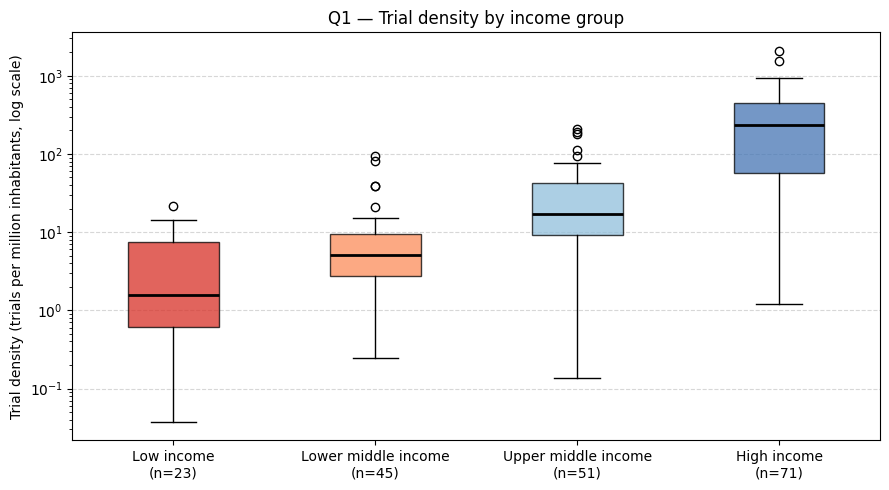

Kruskal-Wallis H = 115.75,  p = 6.352e-25
-> Significant overall difference (reject H0). Running post-hoc pairwise tests.

Pairwise Mann-Whitney U tests (Bonferroni-corrected):
            Group A             Group B  U statistic  p (raw)  p (Bonferroni) Significant (a=0.05)
         Low income Lower middle income        360.0   0.0418          0.2510                   No
         Low income Upper middle income        163.0   0.0000          0.0000                  Yes
         Low income         High income         22.0   0.0000          0.0000                  Yes
Lower middle income Upper middle income        559.0   0.0000          0.0001                  Yes
Lower middle income         High income        120.0   0.0000          0.0000                  Yes
Upper middle income         High income        462.0   0.0000          0.0000                  Yes

Median trial density by income group:
                      n  median    q25     q75
income_group                                

In [ ]:
INCOME_ORDER = [
    "Low income",
    "Lower middle income",
    "Upper middle income",
    "High income",
]

df_q1 = df[df["income_group"].isin(INCOME_ORDER)].copy()
df_q1["income_group"] = pd.Categorical(
    df_q1["income_group"], categories=INCOME_ORDER, ordered=True
)
df_q1 = df_q1.sort_values("income_group")

# Box plot on log scale
fig, ax = plt.subplots(figsize=(9, 5))

groups_data = [
    df_q1[df_q1["income_group"] == g]["trial_density"].values
    for g in INCOME_ORDER
]
group_labels = [f"{g}\n(n={len(d)})" for g, d in zip(INCOME_ORDER, groups_data)]

bp = ax.boxplot(
    groups_data,
    labels=group_labels,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
)

colors = ["#d73027", "#fc8d59", "#91bfdb", "#4575b4"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_yscale("log")
ax.set_ylabel("Trial density (trials per million inhabitants, log scale)")
ax.set_title("Q1 — Trial density by income group")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Kruskal-Wallis test
stat, p_kw = kruskal(*groups_data)
print(f"Kruskal-Wallis H = {stat:.2f},  p = {p_kw:.4g}")

if p_kw < 0.05:
    print("-> Significant overall difference (reject H0). Running post-hoc pairwise tests.\n")
else:
    print("-> No significant overall difference (fail to reject H0).\n")

# Pairwise Mann-Whitney U with Bonferroni correction
pairs = list(combinations(INCOME_ORDER, 2))
n_comparisons = len(pairs)

rows = []
for g1, g2 in pairs:
    d1 = df_q1[df_q1["income_group"] == g1]["trial_density"].values
    d2 = df_q1[df_q1["income_group"] == g2]["trial_density"].values
    u_stat, p_raw = mannwhitneyu(d1, d2, alternative="two-sided")
    p_bonf = min(p_raw * n_comparisons, 1.0)
    rows.append({
        "Group A": g1,
        "Group B": g2,
        "U statistic": round(u_stat, 1),
        "p (raw)": round(p_raw, 4),
        "p (Bonferroni)": round(p_bonf, 4),
        "Significant (a=0.05)": "Yes" if p_bonf < 0.05 else "No",
    })

pairwise_df = pd.DataFrame(rows)
print("Pairwise Mann-Whitney U tests (Bonferroni-corrected):")
print(pairwise_df.to_string(index=False))

# Median summary table
print("\nMedian trial density by income group:")
summary = (
    df_q1.groupby("income_group", observed=True)["trial_density"]
    .agg(n="count", median="median",
         q25=lambda x: x.quantile(0.25),
         q75=lambda x: x.quantile(0.75))
    .round(2)
)
print(summary)

### 3.3 Q2 — Population scaling: is the trial–population relationship proportional?

**Research question:** Does a larger population lead to proportionally more clinical trials, or is the relationship sub- or super-linear?

**Hypotheses:**
- **H₀:** The slope of log₁₀(trial_count) on log₁₀(population) equals 1 — trials scale exactly in proportion to population.
- **H₁:** The slope differs from 1 — large-population countries are either over- or under-represented relative to their population size.

**Method — log-log OLS regression:**

A power-law relationship of the form `trial_count = a · population^β` linearises on the log scale:

```
log10(trial_count) = intercept + β · log10(population)
```

The exponent **β** (the OLS slope) is the quantity of interest:
- β = 1 → perfectly proportional (doubling population ⇒ doubling trials)
- β < 1 → sub-linear (large countries get fewer trials than their size would predict)
- β > 1 → super-linear (large countries attract disproportionately more trials)

We test H₀: β = 1 using a t-test on the estimated coefficient.

OLS: log10(trial_count + 1) ~ log10(population)
  slope (beta) = 0.810  [0.677, 0.944]
  intercept    = -3.337
  R²           = 0.429
  p (slope)    = 6.255e-25

H0: beta = 1  ->  t = -2.801,  p = 0.005614
-> Reject H0: relationship is sub-linear (beta < 1)


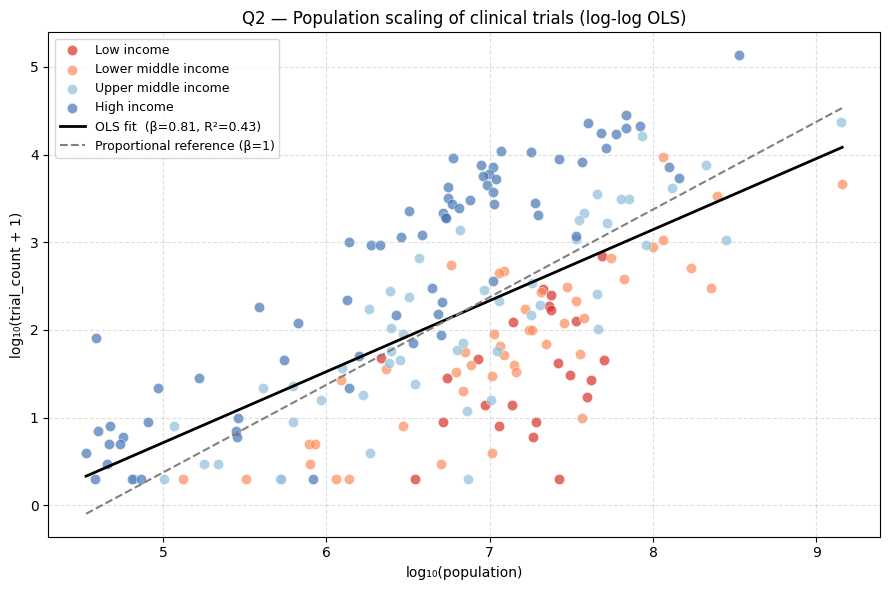

In [ ]:
df_q2 = df[["log_trials", "log_population", "income_group"]].dropna().copy()

model = smf.ols("log_trials ~ log_population", data=df_q2).fit()

slope = model.params["log_population"]
intercept = model.params["Intercept"]
r2 = model.rsquared
ci_low, ci_high = model.conf_int().loc["log_population"]
p_slope = model.pvalues["log_population"]

print("OLS: log10(trial_count + 1) ~ log10(population)")
print(f"  slope (beta) = {slope:.3f}  [{ci_low:.3f}, {ci_high:.3f}]")
print(f"  intercept    = {intercept:.3f}")
print(f"  R²           = {r2:.3f}")
print(f"  p (slope)    = {p_slope:.4g}")

# t-test: is slope significantly different from 1?
se_slope = model.bse["log_population"]
t_stat = (slope - 1.0) / se_slope
from scipy.stats import t as t_dist
df_resid = model.df_resid
p_vs_1 = 2 * t_dist.sf(abs(t_stat), df=df_resid)
print(f"\nH0: beta = 1  ->  t = {t_stat:.3f},  p = {p_vs_1:.4g}")
if p_vs_1 < 0.05:
    direction = "sub-linear (beta < 1)" if slope < 1 else "super-linear (beta > 1)"
    print(f"-> Reject H0: relationship is {direction}")
else:
    print("-> Fail to reject H0: slope is consistent with proportional scaling")

INCOME_COLORS = {
    "Low income": "#d73027",
    "Lower middle income": "#fc8d59",
    "Upper middle income": "#91bfdb",
    "High income": "#4575b4",
}

fig, ax = plt.subplots(figsize=(9, 6))

for group, color in INCOME_COLORS.items():
    mask = df_q2["income_group"] == group
    ax.scatter(
        df_q2.loc[mask, "log_population"],
        df_q2.loc[mask, "log_trials"],
        color=color,
        alpha=0.7,
        edgecolors="white",
        linewidths=0.4,
        s=55,
        label=group,
    )

# Regression line
x_range = np.linspace(df_q2["log_population"].min(), df_q2["log_population"].max(), 200)
y_pred = intercept + slope * x_range
ax.plot(x_range, y_pred, color="black", linewidth=2,
        label=f"OLS fit  (β={slope:.2f}, R²={r2:.2f})")

# Proportional reference line (beta = 1) anchored at the mean
x_mean = df_q2["log_population"].mean()
y_mean = df_q2["log_trials"].mean()
y_ref = y_mean + 1.0 * (x_range - x_mean)
ax.plot(x_range, y_ref, color="grey", linewidth=1.5, linestyle="--",
        label="Proportional reference (β=1)")

ax.set_xlabel("log₁₀(population)")
ax.set_ylabel("log₁₀(trial_count + 1)")
ax.set_title("Q2 — Population scaling of clinical trials (log-log OLS)")
ax.legend(loc="upper left", fontsize=9)
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### 3.4 Q3 — Regional inequality: how concentrated is the global trial distribution?

**Research question:** Is there a systematic difference in trial density across world regions, and how unequal is the global distribution overall?

This section has two complementary parts:

**Part A — Regional medians (box plot)**
We compare median trial density across the seven World Bank regions. This reveals which parts of the world are over- or under-represented relative to their population.

**Part B — Global concentration (Lorenz curve + Gini coefficient)**
We treat trial counts as an "income" distribution across countries and apply tools borrowed from inequality economics:

- The **Lorenz curve** plots the cumulative share of trials (y-axis) against the cumulative share of countries sorted from fewest to most trials (x-axis). Perfect equality is the 45° diagonal; greater bow toward the bottom-right means greater concentration.
- The **Gini coefficient** summarises the Lorenz curve as a single number between 0 (perfect equality) and 1 (one country holds all trials). A Gini above ~0.6 indicates severe concentration.

No formal hypothesis test is applied to the Lorenz/Gini analysis — these are descriptive inequality measures. The regional box plot uses a **Kruskal-Wallis test** (same rationale as Section 3.2: trial density is right-skewed).

Kruskal-Wallis (regional trial density): H = 76.51,  p = 1.872e-14


C:\Users\momch\AppData\Local\Temp\ipykernel_11412\1930433265.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


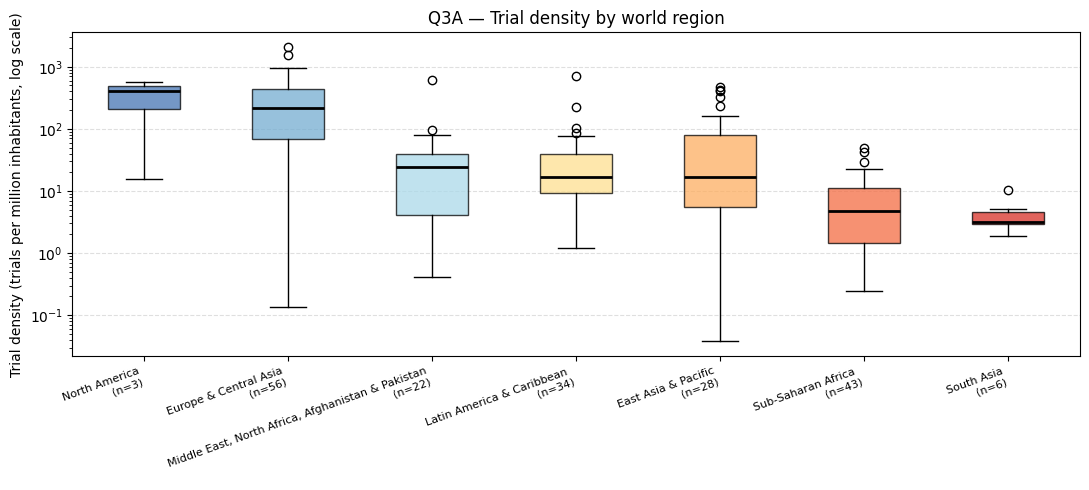


Median trial density by region:
region
North America                                        403.00
Europe & Central Asia                                218.05
Middle East, North Africa, Afghanistan & Pakistan     24.07
Latin America & Caribbean                             16.78
East Asia & Pacific                                   16.55
Sub-Saharan Africa                                     4.70
South Asia                                             3.13


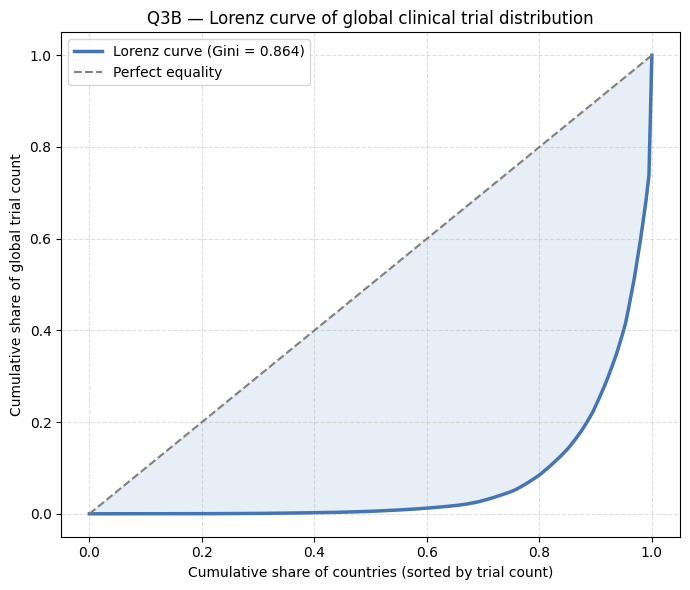


Gini coefficient: 0.864
Top 10% of countries account for 77.6% of all trials


In [13]:
df_q3 = df[["region", "trial_count", "trial_density", "population"]].dropna().copy()

# Part A: Regional trial density

region_medians = (
    df_q3.groupby("region")["trial_density"]
    .median()
    .sort_values(ascending=False)
)

REGION_ORDER = region_medians.index.tolist()

groups_region = [
    df_q3[df_q3["region"] == r]["trial_density"].values
    for r in REGION_ORDER
]

stat_kw, p_kw = kruskal(*groups_region)
print(f"Kruskal-Wallis (regional trial density): H = {stat_kw:.2f},  p = {p_kw:.4g}")

fig, ax = plt.subplots(figsize=(11, 5))

bp = ax.boxplot(
    groups_region,
    labels=[f"{r}\n(n={len(g)})" for r, g in zip(REGION_ORDER, groups_region)],
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    vert=True,
)

region_colors = ["#4575b4", "#74add1", "#abd9e9", "#fee090", "#fdae61", "#f46d43", "#d73027"]
for patch, color in zip(bp["boxes"], region_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_yscale("log")
ax.set_ylabel("Trial density (trials per million inhabitants, log scale)")
ax.set_title("Q3A — Trial density by world region")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.xticks(fontsize=8, rotation=20, ha="right")
plt.tight_layout()
plt.show()

print("\nMedian trial density by region:")
print(region_medians.round(2).to_string())

# Part B: Lorenz curve + Gini coefficient

def gini(values):
    """Compute Gini coefficient for an array of non-negative values."""
    v = np.sort(np.asarray(values, dtype=float))
    n = len(v)
    cumv = np.cumsum(v)
    return (2 * np.sum((np.arange(1, n + 1)) * v) / (n * cumv[-1])) - (n + 1) / n

trial_sorted = np.sort(df_q3["trial_count"].values)
n = len(trial_sorted)
cum_countries = np.concatenate([[0], np.arange(1, n + 1) / n])
cum_trials = np.concatenate([[0], np.cumsum(trial_sorted) / trial_sorted.sum()])

gini_coef = gini(trial_sorted)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(cum_countries, cum_trials, color="#4575b4", linewidth=2.5, label=f"Lorenz curve (Gini = {gini_coef:.3f})")
ax.plot([0, 1], [0, 1], color="grey", linestyle="--", linewidth=1.5, label="Perfect equality")
ax.fill_between(cum_countries, cum_trials, cum_countries, alpha=0.12, color="#4575b4")
ax.set_xlabel("Cumulative share of countries (sorted by trial count)")
ax.set_ylabel("Cumulative share of global trial count")
ax.set_title("Q3B — Lorenz curve of global clinical trial distribution")
ax.legend(fontsize=10)
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

print(f"\nGini coefficient: {gini_coef:.3f}")
top10_share = trial_sorted[int(0.9 * n):].sum() / trial_sorted.sum() * 100
print(f"Top 10% of countries account for {top10_share:.1f}% of all trials")

### 3.5 Q4 — Temporal trends: is the income-group gap growing or shrinking?

**Research question:** How has the global distribution of clinical trials changed over 2000–2024, and is the gap between high- and low-income countries widening or narrowing?

**Data source:** `ct_panel` — a country × year table of trial counts built in Section 2.3. We merge it with income groups from the merged analysis frame `df`. Population is held fixed at the 2023 World Bank reference year (a limitation noted below).

**Analysis steps:**

1. **Absolute volume** — total trials per year by income group (stacked area / line chart). Shows raw growth and which groups drive it.
2. **Trial density over time** — trials per million inhabitants per year per income group. Removes the effect of group size so growth rates are comparable.
3. **Gap trend** — ratio of High-income to Low-income median density per year, regressed on time. A positive slope means the gap is widening; negative means converging.

**Limitation:** Population figures are fixed at 2023. Using a single-year population to compute density for every year between 2000–2024 introduces a small bias — it slightly overstates earlier density (populations were smaller then). Given the scale of the differences between income groups, this does not affect the qualitative conclusions.

In [ ]:
# Merge ct_panel with income group and population from df
panel = ct_panel.merge(
    df[["iso2", "income_group", "population"]].dropna(),
    on="iso2",
    how="inner",
)
panel = panel[panel["income_group"].isin(INCOME_ORDER)]
panel["income_group"] = pd.Categorical(panel["income_group"], categories=INCOME_ORDER, ordered=True)

# ── Part A: Total trials per year by income group ────────────────────────────

annual_total = (
    panel.groupby(["start_year", "income_group"], observed=True)["trial_count"]
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))
for group, color in INCOME_COLORS.items():
    subset = annual_total[annual_total["income_group"] == group]
    ax.plot(subset["start_year"], subset["trial_count"],
            label=group, color=color, linewidth=2, marker="o", markersize=3)

ax.set_xlabel("Year")
ax.set_ylabel("Total trial count")
ax.set_title("Q4A — Total trials per year by income group (2000–2024)")
ax.legend(fontsize=9)
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# ── Part B: Trial density per year by income group ───────────────────────────

# Sum trials and population per income-group-year, then compute density
annual_density = (
    panel.groupby(["start_year", "income_group"], observed=True)
    .agg(trials=("trial_count", "sum"), pop=("population", "sum"))
    .reset_index()
)
annual_density["density"] = annual_density["trials"] / annual_density["pop"] * 1_000_000

fig, ax = plt.subplots(figsize=(11, 5))
for group, color in INCOME_COLORS.items():
    subset = annual_density[annual_density["income_group"] == group]
    ax.plot(subset["start_year"], subset["density"],
            label=group, color=color, linewidth=2, marker="o", markersize=3)

ax.set_xlabel("Year")
ax.set_ylabel("Trials per million inhabitants")
ax.set_title("Q4B — Trial density per year by income group (2000–2024)")
ax.legend(fontsize=9)
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# ── Part C: Gap trend — High / Low income density ratio over time ─────────────

high_density = annual_density[annual_density["income_group"] == "High income"].set_index("start_year")["density"]
low_density  = annual_density[annual_density["income_group"] == "Low income"].set_index("start_year")["density"]
common_years = high_density.index.intersection(low_density.index)

gap = (high_density[common_years] / low_density[common_years]).reset_index()
gap.columns = ["year", "ratio"]

gap_model = smf.ols("ratio ~ year", data=gap).fit()
gap_slope = gap_model.params["year"]
gap_p     = gap_model.pvalues["year"]
gap_r2    = gap_model.rsquared

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(gap["year"], gap["ratio"], color="#4575b4", linewidth=2, marker="o", markersize=4,
        label="High / Low income density ratio")

x_range = np.linspace(gap["year"].min(), gap["year"].max(), 100)
ax.plot(x_range, gap_model.params["Intercept"] + gap_slope * x_range,
        color="black", linestyle="--", linewidth=1.5,
        label=f"OLS trend (slope={gap_slope:+.1f}/yr, p={gap_p:.3g})")

ax.axhline(1, color="grey", linewidth=1, linestyle=":")
ax.set_xlabel("Year")
ax.set_ylabel("Ratio (High income density / Low income density)")
ax.set_title("Q4C — High vs. Low income trial-density gap over time")
ax.legend(fontsize=9)
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

print(f"Gap trend: slope = {gap_slope:+.2f} per year,  p = {gap_p:.4g},  R² = {gap_r2:.3f}")
if gap_p < 0.05:
    direction = "widening" if gap_slope > 0 else "narrowing"
    print(f"-> Significant trend: the High/Low income gap is {direction} over time.")
else:
    print("-> No significant trend: the gap is stable over time.")